In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Carregar os dados
data = {'Size': [750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1300, 1400],
        'Bedrooms':[1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
        'Age': [10, 8, 12, 15, 7, 5, 4, 3, 2, 1, 0, 0],
        'Rent': [1200, 1300, 1500, 1600, 1700, 1800, 2000, 2200, 2400, 2600, 3000, 3500]
         }
df = pd.DataFrame(data)
df


,Size,Bedrooms,Age,Rent
0,750,1,10,1200
1,800,1,8,1300
2,850,2,12,1500
3,900,2,15,1600
4,950,3,7,1700
5,1000,3,5,1800
6,1050,4,4,2000
7,1100,4,3,2200
8,1150,5,2,2400
9,1200,5,1,2600


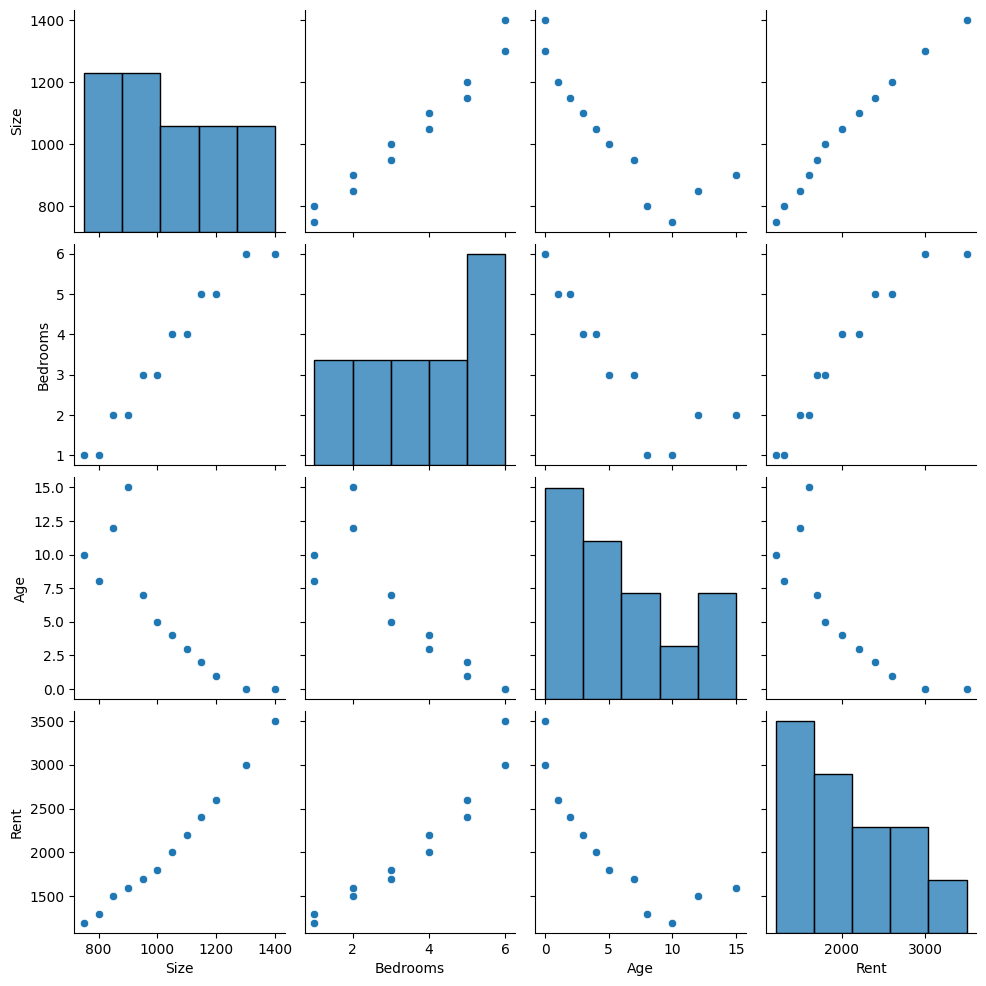

In [13]:
sns.pairplot(df)
plt.show()

In [14]:
df.corr(numeric_only=True)

,Size,Bedrooms,Age,Rent
Size,1.000000,0.981190,-0.855725,0.990306
Bedrooms,0.981190,1.000000,-0.870449,0.957797
Age,-0.855725,-0.870449,1.000000,-0.825115
Rent,0.990306,0.957797,-0.825115,1.000000


In [15]:
X = df[["Size", "Bedrooms", "Age"]]
y = df["Rent"]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
#Treinamento do modelo
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
#Fazer previsões
y_pred = model.predict(X_test)
#Avaliação do modelo

In [19]:
#Avaliação (RMSE e R²)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2


(np.float64(114.00642677456682), 0.9781758977400854)

In [20]:
#Comparação Real vs Predito
comparison = pd.DataFrame({
    "Real": y_test.values,
    "Predito": y_pred
})

comparison


,Real,Predito
0,3000,2947.544033
1,2600,2598.261931
2,1200,1009.637854
